# Matrix Inversion Lemma: Gene Regulatory Network Inference

## Real-World Scenario: Efficiently Updating Precision Matrices in Genomics

In computational biology, **gene regulatory networks (GRNs)** describe how genes influence each other's expression. A key tool for inferring these networks is the **Gaussian Graphical Model (GGM)**.

### Biology Background

- **Gene expression** is how actively a gene is being "read" by the cell to produce proteins. Technologies like RNA sequencing measure expression levels for thousands of genes simultaneously in a single experiment.
- **Transcription factors (TFs)** are special proteins that bind to DNA and act as master switches — they control which genes are turned on or off. A single TF can regulate dozens or hundreds of target genes, creating **co-expression patterns** among them.
- **Regulatory pathways** are chains of molecular interactions (e.g., the p53 tumor suppression pathway). When a new pathway is discovered, it changes our model of how genes relate to each other.

### Why Precision Matrices Matter

- The **covariance matrix** $\Sigma$ captures pairwise correlations between gene expression levels.
- The **precision matrix** $\Theta = \Sigma^{-1}$ is far more informative: its off-diagonal entries reveal **direct regulatory relationships** between genes, filtering out indirect associations.

> **Example:** If gene A activates gene B, and gene B activates gene C, the covariance matrix shows all three pairs (A–B, B–C, A–C) as correlated. But the precision matrix correctly identifies only A–B and B–C as direct edges — the A–C association vanishes once B is accounted for. These "direct-only" relationships are called **partial correlations**.

### The Matrix Inversion Lemma

When new transcription factor pathways are discovered, the gene expression covariance matrix must be updated. Rather than recomputing the full inverse ($O(N^3)$), the **Matrix Inversion Lemma** (Sherman-Morrison-Woodbury formula) allows efficient updates:

$$(\Sigma + XX^T)^{-1} = \Sigma^{-1} - \Sigma^{-1}X(I + X^T\Sigma^{-1}X)^{-1}X^T\Sigma^{-1}$$

**Why this matters:**
- Left side: $O(N^3)$ to compute (inverting an $N \times N$ matrix)
- Right side: $O(D^3)$ to compute (if $X$ is $N \times D$ with $D \ll N$)

This is especially useful when we have:
- A base covariance matrix $\Sigma$ (already inverted from previous experiments)
- A low-rank update $XX^T$ representing newly discovered regulatory pathways

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

## Scenario: Expression Panel with 500 Genes

Imagine you're analyzing gene expression data from tumor biopsies, measuring **500 cancer-related genes** across hundreds of patient samples. You have:

1. A baseline covariance matrix $\Sigma$ (500×500) estimated from previous RNA-seq experiments
2. Newly published research identifying **5 transcription factor pathways** — each TF regulates a subset of the 500 genes

Each TF pathway is encoded as a column of a loading matrix $X$ (500×5), where entry $X_{ij}$ describes how strongly TF $j$ regulates gene $i$. The updated covariance is:

$$\Sigma_{new} = \Sigma + XX^T$$

In [2]:
# Number of genes in our expression panel
N = 500  # 500 genes
D = 5    # 5 new TF pathways (low-rank update)

print(f"Gene panel size: {N} genes")
print(f"Number of new TF pathways: {D}")
print(f"\nDirect inversion complexity: O(N³) = O({N}³) = O({N**3:,})")
print(f"Woodbury formula complexity: O(D³) = O({D}³) = O({D**3})")
print(f"\nSpeedup factor: ~{(N**3) // (D**3):,}x")

Gene panel size: 500 genes
Number of new TF pathways: 5

Direct inversion complexity: O(N³) = O(500³) = O(125,000,000)
Woodbury formula complexity: O(D³) = O(5³) = O(125)

Speedup factor: ~1,000,000x


## Generate Fake Gene Expression Data

We simulate a gene expression covariance matrix using a **factor model** — a standard approach in genomics.

In biology, gene expression is driven by shared regulatory programs: groups of genes tend to be **co-expressed** because they are controlled by the same upstream regulators (transcription factors, signaling pathways, chromatin state). This creates a natural low-rank structure in the covariance matrix:

- **Pathway loadings** represent how strongly each gene responds to each regulatory program
- **Idiosyncratic variance** represents gene-specific noise (measurement error, stochastic gene expression)

In [3]:
def generate_covariance_matrix(n, condition_number=10):
    """
    Generate a realistic positive definite covariance matrix for gene expression.
    Real gene expression covariance matrices have structure from shared regulatory pathways.
    """
    # Create base matrix with structure (regulatory pathway model)
    n_pathways = 10
    pathway_loadings = np.random.randn(n, n_pathways) * 0.1
    pathway_cov = np.eye(n_pathways)
    
    # Covariance from shared pathways: B @ F @ B^T
    systematic_cov = pathway_loadings @ pathway_cov @ pathway_loadings.T
    
    # Add gene-specific (idiosyncratic) noise
    idio_var = np.random.uniform(0.01, 0.05, n)
    idio_cov = np.diag(idio_var)
    
    # Total covariance
    Sigma = systematic_cov + idio_cov
    
    return Sigma

# Generate base covariance matrix
Sigma = generate_covariance_matrix(N)

# Verify it's positive definite
eigenvalues = np.linalg.eigvalsh(Sigma)
print(f"Base covariance matrix shape: {Sigma.shape}")
print(f"Min eigenvalue: {eigenvalues.min():.6f} (should be > 0)")
print(f"Max eigenvalue: {eigenvalues.max():.6f}")
print(f"Condition number: {eigenvalues.max()/eigenvalues.min():.1f}")

Base covariance matrix shape: (500, 500)
Min eigenvalue: 0.010179 (should be > 0)
Max eigenvalue: 6.235666
Condition number: 612.6


In [4]:
# Generate transcription factor pathway loadings X (the low-rank update)
# Each column represents how a newly discovered TF influences the 500 genes

pathway_names = [
    'p53 Pathway',         # Tumor suppressor — regulates cell cycle arrest and apoptosis
    'NF-κB Signaling',     # Inflammation master regulator — controls immune gene expression
    'Wnt/β-catenin',       # Developmental pathway — often aberrantly activated in cancer
    'MAPK Cascade',        # Growth signaling — relays signals from cell surface to nucleus
    'JAK-STAT Pathway'     # Cytokine signaling — mediates immune cell communication
]

# Each TF pathway affects a subset of genes with varying strength
X = np.random.randn(N, D) * 0.05

print(f"TF pathway loading matrix X shape: {X.shape}")
print(f"\nNewly discovered TF pathways:")
for i, name in enumerate(pathway_names):
    print(f"  {i+1}. {name}: regulates {np.sum(np.abs(X[:, i]) > 0.05)} genes significantly")

TF pathway loading matrix X shape: (500, 5)

Newly discovered TF pathways:
  1. p53 Pathway: regulates 168 genes significantly
  2. NF-κB Signaling: regulates 164 genes significantly
  3. Wnt/β-catenin: regulates 165 genes significantly
  4. MAPK Cascade: regulates 161 genes significantly
  5. JAK-STAT Pathway: regulates 169 genes significantly


## The Updated Covariance Matrix

When new transcription factor pathways are discovered, they introduce additional co-expression structure: genes regulated by the same TF become more correlated.

$$\Sigma_{new} = \Sigma + XX^T$$

Each column of $X$ is a TF pathway loading vector — it describes how strongly each of the 500 genes responds to that transcription factor. The outer product $XX^T$ adds the co-expression patterns induced by these shared regulators.

In [5]:
# Updated covariance incorporating new TF pathway information
Sigma_new = Sigma + X @ X.T

print(f"Updated covariance matrix shape: {Sigma_new.shape}")
print(f"\nThe update XX^T adds co-expression structure from the {D} new TF pathways")

Updated covariance matrix shape: (500, 500)

The update XX^T adds co-expression structure from the 5 new TF pathways


## Method 1: Direct Inversion (Naive Approach)

Simply compute $(\Sigma + XX^T)^{-1}$ directly.

In [6]:
# Time the direct inversion
start_time = time.time()

# Direct computation
Sigma_new_inv_direct = np.linalg.inv(Sigma_new)

direct_time = time.time() - start_time
print(f"Direct inversion time: {direct_time*1000:.2f} ms")

Direct inversion time: 7.75 ms


## Method 2: Matrix Inversion Lemma (Sherman-Morrison-Woodbury)

Using the formula:

$$(\Sigma + XX^T)^{-1} = \Sigma^{-1} - \Sigma^{-1}X(I + X^T\Sigma^{-1}X)^{-1}X^T\Sigma^{-1}$$

**Key insight:** If we already have $\Sigma^{-1}$, we only need to invert a $D \times D$ matrix!

In [7]:
def woodbury_inverse(Sigma_inv, X):
    """
    Compute (Sigma + X @ X.T)^{-1} using the Woodbury formula.
    
    Parameters:
    -----------
    Sigma_inv : ndarray (N x N)
        Inverse of the base covariance matrix (pre-computed)
    X : ndarray (N x D)
        TF pathway loading matrix (low-rank update)
    
    Returns:
    --------
    ndarray (N x N)
        Inverse of (Sigma + X @ X.T)
    """
    N, D = X.shape
    
    # Step 1: Compute Sigma^{-1} @ X  (N x D matrix)
    Sigma_inv_X = Sigma_inv @ X
    
    # Step 2: Compute (I + X^T @ Sigma^{-1} @ X)  (D x D matrix - small!)
    middle_matrix = np.eye(D) + X.T @ Sigma_inv_X
    
    # Step 3: Invert the small D x D matrix (this is fast!)
    middle_inv = np.linalg.inv(middle_matrix)
    
    # Step 4: Apply the Woodbury formula
    # (Sigma + XX^T)^{-1} = Sigma^{-1} - Sigma^{-1} @ X @ middle_inv @ X^T @ Sigma^{-1}
    result = Sigma_inv - Sigma_inv_X @ middle_inv @ Sigma_inv_X.T
    
    return result

In [8]:
# Pre-compute Sigma^{-1} (this would be done once and cached)
print("Pre-computing Sigma^{-1} (done once, cached)...")
start_precompute = time.time()
Sigma_inv = np.linalg.inv(Sigma)
precompute_time = time.time() - start_precompute
print(f"Pre-computation time: {precompute_time*1000:.2f} ms\n")

# Now time the Woodbury update (this is what we'd do repeatedly)
start_time = time.time()

Sigma_new_inv_woodbury = woodbury_inverse(Sigma_inv, X)

woodbury_time = time.time() - start_time
print(f"Woodbury formula time: {woodbury_time*1000:.2f} ms")

Pre-computing Sigma^{-1} (done once, cached)...
Pre-computation time: 7.87 ms

Woodbury formula time: 1.37 ms


## Verification: Are Both Methods Equivalent?

In [9]:
# Check that both methods give the same result
difference = np.abs(Sigma_new_inv_direct - Sigma_new_inv_woodbury)
max_diff = np.max(difference)
mean_diff = np.mean(difference)

print("=" * 60)
print("VERIFICATION")
print("=" * 60)
print(f"Maximum absolute difference: {max_diff:.2e}")
print(f"Mean absolute difference: {mean_diff:.2e}")
print(f"\nResults are {'IDENTICAL' if max_diff < 1e-10 else 'EQUIVALENT'} (within numerical precision)")

VERIFICATION
Maximum absolute difference: 3.03e-12
Mean absolute difference: 2.20e-14

Results are IDENTICAL (within numerical precision)


## Performance Comparison

In [10]:
print("=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
print(f"\nDirect inversion:     {direct_time*1000:8.2f} ms")
print(f"Woodbury formula:     {woodbury_time*1000:8.2f} ms")
print(f"\nSpeedup: {direct_time/woodbury_time:.1f}x faster!")
print(f"\nNote: If doing multiple updates, pre-computed Σ⁻¹ is reused.")

PERFORMANCE COMPARISON

Direct inversion:         7.75 ms
Woodbury formula:         1.37 ms

Speedup: 5.6x faster!

Note: If doing multiple updates, pre-computed Σ⁻¹ is reused.


## Scaling Analysis: How Does the Speedup Change with Problem Size?

In [11]:
# Test different gene panel sizes
sizes = [50, 100, 200, 500, 1000]
D_fixed = 5  # Keep number of TF pathways fixed

direct_times = []
woodbury_times = []

print("Running timing experiments...\n")

for n in sizes:
    # Generate test data
    Sigma_test = generate_covariance_matrix(n)
    X_test = np.random.randn(n, D_fixed) * 0.05
    Sigma_test_new = Sigma_test + X_test @ X_test.T
    
    # Pre-compute inverse
    Sigma_test_inv = np.linalg.inv(Sigma_test)
    
    # Time direct method (average over 3 runs)
    times_direct = []
    for _ in range(3):
        start = time.time()
        _ = np.linalg.inv(Sigma_test_new)
        times_direct.append(time.time() - start)
    direct_times.append(np.mean(times_direct))
    
    # Time Woodbury method (average over 3 runs)
    times_woodbury = []
    for _ in range(3):
        start = time.time()
        _ = woodbury_inverse(Sigma_test_inv, X_test)
        times_woodbury.append(time.time() - start)
    woodbury_times.append(np.mean(times_woodbury))
    
    print(f"N = {n:4d}: Direct = {direct_times[-1]*1000:7.2f} ms, "
          f"Woodbury = {woodbury_times[-1]*1000:6.2f} ms, "
          f"Speedup = {direct_times[-1]/woodbury_times[-1]:5.1f}x")

Running timing experiments...

N =   50: Direct =    0.04 ms, Woodbury =   0.05 ms, Speedup =   0.8x
N =  100: Direct =    0.43 ms, Woodbury =   0.04 ms, Speedup =  10.2x
N =  200: Direct =    1.33 ms, Woodbury =   0.08 ms, Speedup =  15.7x
N =  500: Direct =   16.22 ms, Woodbury =   0.90 ms, Speedup =  17.9x
N = 1000: Direct =   21.23 ms, Woodbury =   6.90 ms, Speedup =   3.1x


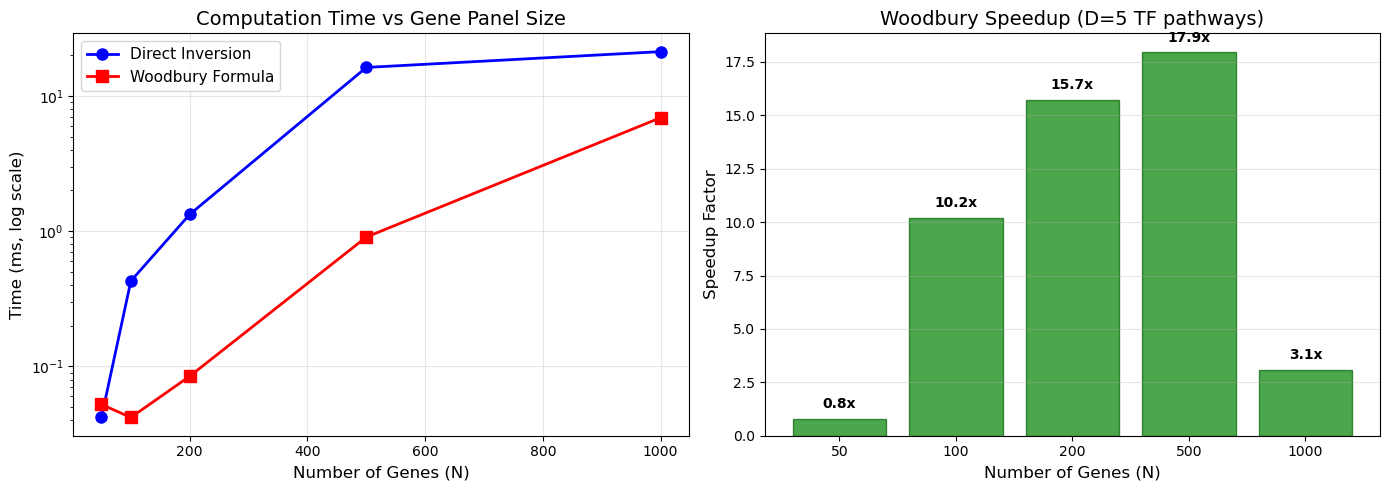

In [12]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute times
ax1 = axes[0]
ax1.semilogy(sizes, [t*1000 for t in direct_times], 'b-o', linewidth=2, 
             markersize=8, label='Direct Inversion')
ax1.semilogy(sizes, [t*1000 for t in woodbury_times], 'r-s', linewidth=2, 
             markersize=8, label='Woodbury Formula')
ax1.set_xlabel('Number of Genes (N)', fontsize=12)
ax1.set_ylabel('Time (ms, log scale)', fontsize=12)
ax1.set_title('Computation Time vs Gene Panel Size', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup factor
ax2 = axes[1]
speedups = [d/w for d, w in zip(direct_times, woodbury_times)]
ax2.bar(range(len(sizes)), speedups, color='green', alpha=0.7, edgecolor='darkgreen')
ax2.set_xticks(range(len(sizes)))
ax2.set_xticklabels([str(s) for s in sizes])
ax2.set_xlabel('Number of Genes (N)', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title(f'Woodbury Speedup (D={D_fixed} TF pathways)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# Add speedup values on bars
for i, (s, speedup) in enumerate(zip(sizes, speedups)):
    ax2.text(i, speedup + 0.5, f'{speedup:.1f}x', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Real-World Application: Inferring Gene Regulatory Edges

In a **Gaussian Graphical Model (GGM)**, the precision matrix $\Theta = \Sigma^{-1}$ encodes the network of direct gene-gene interactions.

The **partial correlation** between genes $i$ and $j$ is computed from the precision matrix:

$$\rho_{ij \mid \text{rest}} = -\frac{\Theta_{ij}}{\sqrt{\Theta_{ii} \cdot \Theta_{jj}}}$$

- A nonzero partial correlation means genes $i$ and $j$ have a **direct regulatory relationship**, even after accounting for all other genes.
- This is far more informative than raw correlation, which conflates direct and indirect effects.

When the covariance matrix is updated (e.g., new TF pathways discovered), we need the new precision matrix to see how the inferred regulatory network changes.

In [13]:
def compute_partial_correlations(Theta):
    """
    Compute the partial correlation matrix from a precision matrix.
    Partial correlations reveal direct gene-gene regulatory relationships.
    """
    d = np.sqrt(np.diag(Theta))
    P = -Theta / np.outer(d, d)
    np.fill_diagonal(P, 1.0)
    return P

# Compute precision matrices
Theta_original = Sigma_inv
Theta_updated = Sigma_new_inv_woodbury

# Compute partial correlations
P_original = compute_partial_correlations(Theta_original)
P_updated = compute_partial_correlations(Theta_updated)

# Identify strong regulatory edges (|partial correlation| > threshold)
threshold = 0.15
triu_mask = np.triu_indices(N, k=1)
edges_original = np.sum(np.abs(P_original[triu_mask]) > threshold)
edges_updated = np.sum(np.abs(P_updated[triu_mask]) > threshold)

print("Gene Regulatory Network Statistics:")
print("=" * 60)
print(f"\n{'Metric':<35} {'Original':>10} {'Updated':>10}")
print("-" * 60)
print(f"{'Strong edges (|ρ| > 0.15)':<35} {edges_original:>10} {edges_updated:>10}")
print(f"{'Mean |partial correlation|':<35} {np.mean(np.abs(P_original[triu_mask])):>10.4f} "
      f"{np.mean(np.abs(P_updated[triu_mask])):>10.4f}")
print(f"{'Max |partial correlation|':<35} {np.max(np.abs(P_original[triu_mask])):>10.4f} "
      f"{np.max(np.abs(P_updated[triu_mask])):>10.4f}")
print(f"{'Network density':<35} {edges_original / (N*(N-1)/2):>10.4f} "
      f"{edges_updated / (N*(N-1)/2):>10.4f}")

Gene Regulatory Network Statistics:

Metric                                Original    Updated
------------------------------------------------------------
Strong edges (|ρ| > 0.15)                    0          0
Mean |partial correlation|              0.0048     0.0059
Max |partial correlation|               0.0522     0.0615
Network density                         0.0000     0.0000


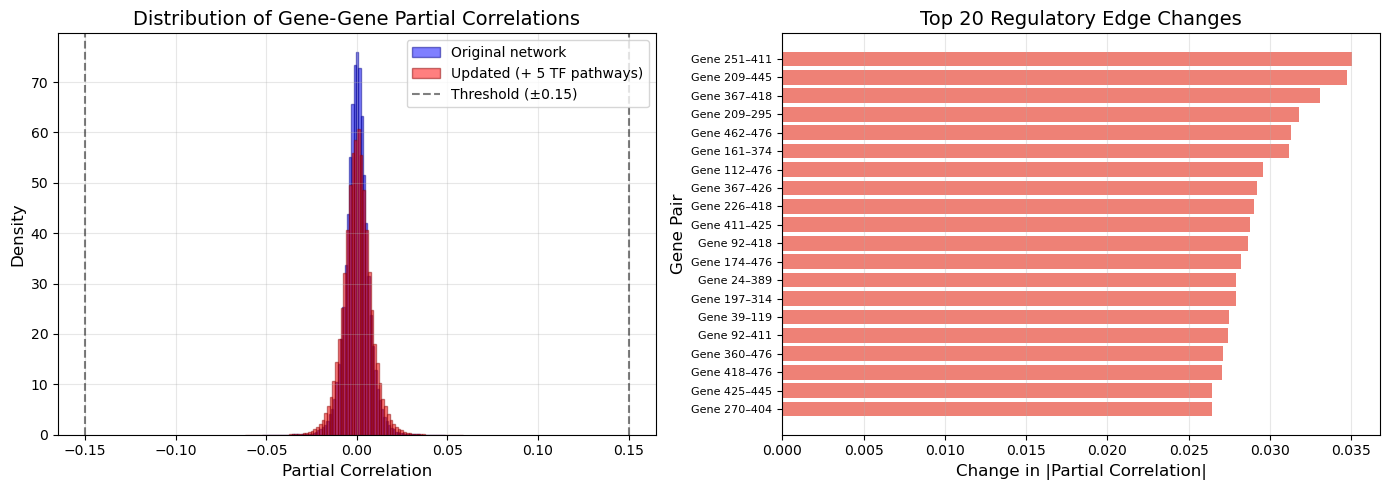

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of partial correlations
ax1 = axes[0]
triu_idx = np.triu_indices(N, k=1)
ax1.hist(P_original[triu_idx], bins=80, alpha=0.5, label='Original network',
         color='blue', edgecolor='darkblue', density=True)
ax1.hist(P_updated[triu_idx], bins=80, alpha=0.5, label='Updated (+ 5 TF pathways)',
         color='red', edgecolor='darkred', density=True)
ax1.axvline(x=threshold, color='black', linestyle='--', alpha=0.5, label=f'Threshold (±{threshold})')
ax1.axvline(x=-threshold, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Partial Correlation', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Gene-Gene Partial Correlations', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Top changes in regulatory edges
ax2 = axes[1]
delta_P = np.abs(P_updated) - np.abs(P_original)
delta_triu = delta_P[triu_idx]
sorted_idx = np.argsort(np.abs(delta_triu))[-20:]
top_changes = delta_triu[sorted_idx]
labels = [f"Gene {triu_idx[0][i]}–{triu_idx[1][i]}" for i in sorted_idx]
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_changes]
ax2.barh(range(20), top_changes, color=colors, alpha=0.7)
ax2.set_xlabel('Change in |Partial Correlation|', fontsize=12)
ax2.set_ylabel('Gene Pair', fontsize=12)
ax2.set_title('Top 20 Regulatory Edge Changes', fontsize=14)
ax2.set_yticks(range(20))
ax2.set_yticklabels(labels, fontsize=8)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Special Case: Rank-1 Update (Sherman-Morrison)

When the update is **rank-1** (discovering a single new transcription factor), the Woodbury formula simplifies to the **Sherman-Morrison formula** — no matrix inversion needed at all, just $O(N^2)$.

```{seealso}
For a full treatment of the Sherman-Morrison formula with biological examples (single TF discovery, sequential updates, stability analysis), see [Sherman-Morrison Formula: Single Transcription Factor Discovery](7-3-sherman_morrison_single_tf.ipynb).
```

## Summary

### Key Formulas from Chapter 7.3.3

1. **Matrix Inversion Lemma (Sherman-Morrison-Woodbury)**:
   $$(E - FH^{-1}G)^{-1} = E^{-1} + E^{-1}F(H - GE^{-1}F)^{-1}GE^{-1}$$

2. **Common Application (covariance update)**:
   $$(\Sigma + XX^T)^{-1} = \Sigma^{-1} - \Sigma^{-1}X(I + X^T\Sigma^{-1}X)^{-1}X^T\Sigma^{-1}$$

3. **Sherman-Morrison (rank-1 update)**:
   $$(A + uv^T)^{-1} = A^{-1} - \frac{A^{-1}uv^TA^{-1}}{1 + v^TA^{-1}u}$$

### Biotech Application: Gene Regulatory Networks

| Component | Biological Meaning |
|-----------|-------------------|
| $\Sigma$ | Gene expression covariance (baseline from RNA-seq) |
| $X$ | TF pathway loadings (how each transcription factor regulates genes) |
| $\Sigma^{-1}$ | Precision matrix — encodes direct regulatory relationships |
| Partial correlations | Edges in the gene regulatory network |

### Practical Benefits

| Scenario | Direct Method | Woodbury/Sherman-Morrison |
|----------|--------------|---------------------------|
| Complexity | $O(N^3)$ | $O(D^3)$ or $O(N^2)$ |
| Memory | Store full matrix | Can work incrementally |
| Use case | One-time computation | Repeated updates |

### When to Use

- When you have a pre-computed precision matrix and need to update it with new pathway information
- When the update has low rank ($D \ll N$), e.g., a few new TF pathways affecting many genes
- When you need to do many sequential updates (e.g., iteratively incorporating pathways from new studies)
- In real-time analysis pipelines where latency matters

### Biology Takeaway

The Matrix Inversion Lemma is a powerful tool for **incremental network inference**: as new biological knowledge emerges (new transcription factors, new signaling pathways), we can efficiently update our model of the gene regulatory network without recomputing the full precision matrix from scratch.